## Prediction of speaker dataset

In [52]:
from preprocessing_class import Preprocessing, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
import numpy as np
import string
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
# load dataset
alltxt, alllabs = load_pres("Dataset/corpus.tache1.learn.utf8")
alltxt, alllabs = np.array(alltxt), np.array(alllabs)

In [62]:
# M = -1, C = 1
len(alltxt), len(alllabs), np.unique(alllabs)

(57413, 57413, array([-1,  1]))

### Split of the dataset

In [78]:
# train test split here for test in final prediction
strat_split = StratifiedShuffleSplit(1, test_size=0.2, random_state=0)

for i, (train_idx, test_idx) in enumerate(strat_split.split(alltxt, alllabs)):
    print(i)
X_train, y_train, X_test, y_test = alltxt[train_idx], alllabs[train_idx], alltxt[test_idx], alllabs[test_idx]

# further split the train 
for i, (train_idx, test_idx) in enumerate(strat_split.split(X_train, y_train)):
    print(i)
X_train_sub, y_train_sub, X_val, y_val = X_train[train_idx], y_train[train_idx], X_train[test_idx], y_train[test_idx]

0
0


In [77]:
len(X_train_sub), len(y_train_sub), len(X_val), len(y_val), len(X_train), len(y_train), len(X_test), len(y_test)

(36744, 36744, 9186, 9186, 45930, 45930, 11483, 11483)

## Experiment 1

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french.

Vectorizer:
- CountVectorizer

Model:
- Logistic Regression

In [150]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [80]:
# vectorization  
#TODO limit to X vocabulary

final_stopwords_list = stopwords.words('french') # stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.99, min_df=0.01, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer
    ## to implement more embeddings 

def build_embeddings():
    pass

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

In [ ]:
# building vectorizer on the train set

vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=None, preprocessor=prep)

# train on the sub train
vectorised_train_sub = vectoriser.fit_transform(X_train_sub)
vectorised_val = vectoriser.transform(X_val)

In [99]:
# get the vocabulary and the frequency -> used to check and restreint vocab

import pandas as pd

word_counts = vectorised_train_sub.sum(axis=0).A1  # .A1 flattens it into a 1D array
words = vectoriser.get_feature_names_out()

df_vocab = pd.DataFrame({'word': words, 'count': word_counts})
df_ranked = df_vocab.sort_values(by='count', ascending=False)

print(df_ranked.head(10))

       word  count
120    plus   4755
74   france   3320
27    cette   3135
114    pays   2865
12    aussi   2789
162    être   2419
148    tout   2371
103     nom   2280
147    tous   2212
20     bien   1895


In [100]:
len(df_ranked)

163

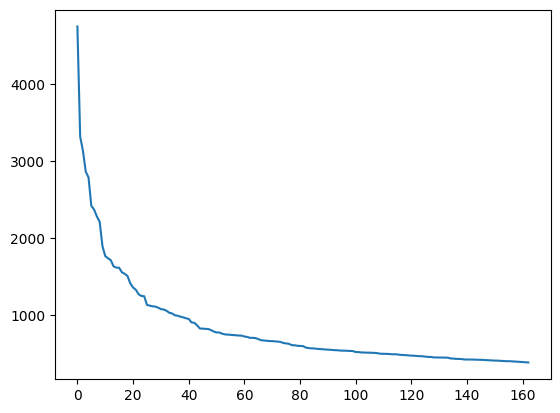

In [101]:
# distribution
plt.plot(df_ranked["count"].head(250).values) # 161 words vocab ok
# plt.yscale("log")

### Running models
#### On simple split

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(solver=solver,max_iter=max_iter) 

def pipeline(model, X_train, y_train, X_test, y_test):
    # fit and preidct Xtrain, Xtest 
    model.fit(X_train,y_train)

    # preds
    y_pred_train = model.predict(X_train)
    ypred_train_prob = model.predict_proba(X_train) # probas for ROC

    y_pred = model.predict(X_test)
    ypred_prob = model.predict_proba(X_test)

    print(f1_score(y_train,y_pred_train),f1_score(y_test,y_pred))
    print(average_precision_score(y_train,y_pred_train), average_precision_score(y_test,y_pred))
    # print(roc_auc_score(y_train, ypred_train_prob), f1_score(y_test,ypred_prob))

    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train)
    plt.show()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.show()

    return model

0.9329498525073746 0.9327206315541416
0.881590970267907 0.8802437575250969


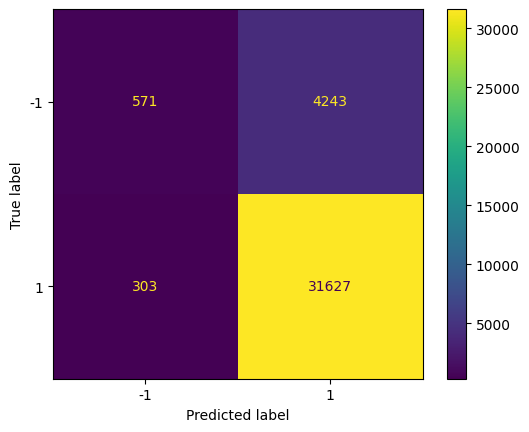

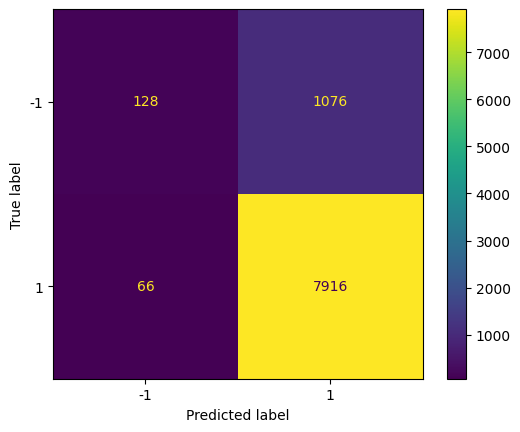

In [105]:
lr = build_model(name="logreg")
lr = pipeline(lr, vectorised_train_sub, y_train_sub, vectorised_val, y_val)

#### Cross validation, then test

In [143]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# Plot CV train vs validation metrics across folds + test as reference line

def plot(train_cv_metrics, val_cv_metrics, test_metrics):

    metric_names = ["AUC", "F1", "Average Precision", "Recall", "Precision"]
    folds = np.arange(1, len(val_cv_metrics["AUC"]) + 1)

    fig, axes = plt.subplots(1, len(metric_names), figsize=(24, 4), sharex=True)

    for ax, metric_name in zip(axes, metric_names):
        train_vals = train_cv_metrics[metric_name]
        val_vals = val_cv_metrics[metric_name]
        test_val = test_metrics[metric_name]

        ax.plot(folds, train_vals, marker="o", label="Train CV")
        ax.plot(folds, val_vals, marker="o", label="Validation CV")
        ax.axhline(test_val, linestyle="--", linewidth=2, label="Test")

        ax.set_title(metric_name)
        ax.set_xlabel("Fold")
        ax.set_xticks(folds)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Score")
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3)
    plt.suptitle("Cross-validation metrics (Train vs Validation) with Test reference", y=1.12)
    plt.tight_layout()
    plt.legend()
    plt.show()

def cv_train(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test, cv=5, test_size=0.2):
    # split in train val, do a cross validation, then evaluate on the final test set
    # takes in untrained model

    train_cv_metrics = {
        "AUC": [],
        "F1": [],
        "Average Precision": [],
        "Recall": [],
        "Precision": [],
    }

    val_cv_metrics = {
        "AUC": [],
        "F1": [],
        "Average Precision": [],
        "Recall": [],
        "Precision": [],
    }

    # splits
    cv_splits = StratifiedShuffleSplit(cv, test_size=test_size, random_state=0)
    for i, (train_idx, test_idx) in enumerate(cv_splits.split(X_train, y_train)):
        print("Fold ", i)
        X_train_sub, y_train_sub, X_val, y_val = X_train[train_idx], y_train[train_idx], X_train[test_idx], y_train[test_idx]

        # vectorising
        vectoriser = build_vectorizer(**vect_kwargs)

        # train on the sub train
        vect_train_sub = vectoriser.fit_transform(X_train_sub)
        vect_val = vectoriser.transform(X_val)

        clf = model(**kwargs)
        clf.fit(vect_train_sub, y_train_sub)

        # predictions
        y_pred_train = clf.predict(vect_train_sub)
        ypred_train_prob = clf.predict_proba(vect_train_sub)[:, 1]  # probas for ROC

        y_pred = clf.predict(vect_val)
        ypred_prob = clf.predict_proba(vect_val)[:, 1]

        # evaluation
        f1_train, f1_val = f1_score(y_train_sub, y_pred_train), f1_score(y_val, y_pred)
        ap_train, ap_val = average_precision_score(y_train_sub, y_pred_train), average_precision_score(y_val, y_pred)
        auc_train, auc_val = roc_auc_score(y_train_sub, ypred_train_prob), roc_auc_score(y_val, ypred_prob)
        prec_train, prec_val = precision_score(y_train_sub, y_pred_train), precision_score(y_val, y_pred)
        rec_train, rec_val = recall_score(y_train_sub, y_pred_train), recall_score(y_val, y_pred)

        train_cv_metrics["AUC"].append(auc_train)
        train_cv_metrics["F1"].append(f1_train)
        train_cv_metrics["Average Precision"].append(ap_train)
        train_cv_metrics["Recall"].append(rec_train)
        train_cv_metrics["Precision"].append(prec_train)

        val_cv_metrics["AUC"].append(auc_val)
        val_cv_metrics["F1"].append(f1_val)
        val_cv_metrics["Average Precision"].append(ap_val)
        val_cv_metrics["Recall"].append(rec_val)
        val_cv_metrics["Precision"].append(prec_val)

    # final test evaluation
    vectoriser = build_vectorizer(**vect_kwargs)

    vect_train = vectoriser.fit_transform(X_train)
    vect_test = vectoriser.transform(X_test)

    clf = model(**kwargs)
    clf.fit(vect_train, y_train)

    y_pred_train = clf.predict(vect_train)
    ypred_train_prob = clf.predict_proba(vect_train)[:, 1]  # probas for ROC

    y_pred = clf.predict(vect_test)
    ypred_prob = clf.predict_proba(vect_test)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

    plot(train_cv_metrics, val_cv_metrics, test_metrics)

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.736157413957766
F1: 0.9329732152334674
Average Precision: 0.8812697055945661
Recall: 0.9909801563439568
Precision: 0.8813816155988858

Final Test Results:
AUC: 0.7349114230709555
F1: 0.9327544712377897
Average Precision: 0.8812691298536856
Recall: 0.990479053918621
Precision: 0.881387675020066


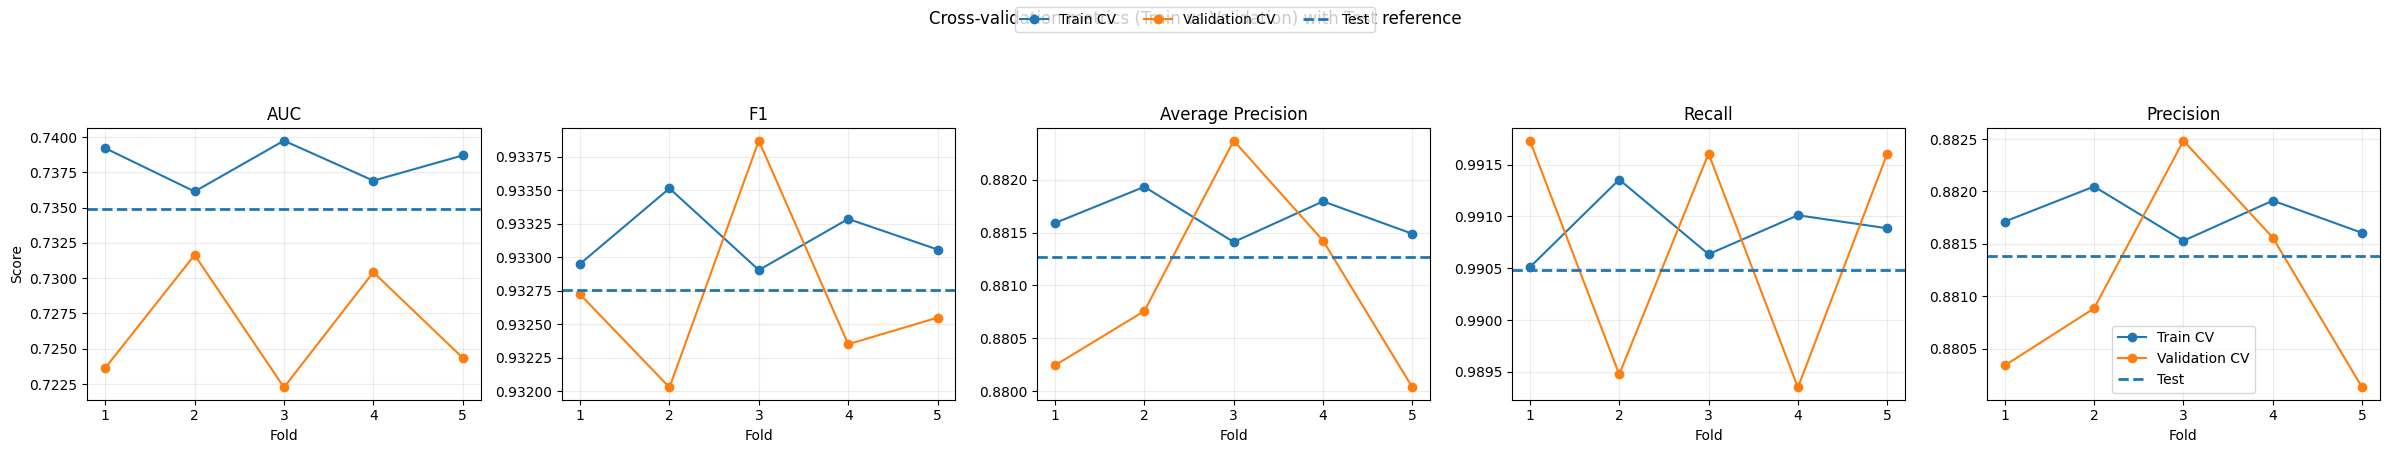

In [144]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"count", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

#### Model on final train and test 

In [153]:
def eval_test(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test):
    # vectorising
    vectorizer = build_vectorizer(**vect_kwargs)
    vect_train = vectorizer.fit_transform(X_train)
    vect_test = vectorizer.transform(X_test)

    clf = model(**kwargs)
    clf.fit(vect_train, y_train)

    y_pred_train = clf.predict(vect_train)
    ypred_train_prob = clf.predict_proba(vect_train)[:, 1]  # probas for ROC

    y_pred = clf.predict(vect_test)
    ypred_prob = clf.predict_proba(vect_test)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [154]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"count", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.736157413957766
F1: 0.9329732152334674
Average Precision: 0.8812697055945661
Recall: 0.9909801563439568
Precision: 0.8813816155988858

Final Test Results:
AUC: 0.7349114230709555
F1: 0.9327544712377897
Average Precision: 0.8812691298536856
Recall: 0.990479053918621
Precision: 0.881387675020066


## Experiment 2

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french.

Vectorizer:
- TfidfVectorizer

Model:
- Logistic Regression

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.7314232679458784
F1: 0.9317057154248458
Average Precision: 0.8756686900695206
Recall: 0.9953648025656444
Precision: 0.8756998633337741

Final Test Results:
AUC: 0.7253776247944814
F1: 0.9317254000281545
Average Precision: 0.8759902419296897
Recall: 0.9949889757466426
Precision: 0.8760257654636902


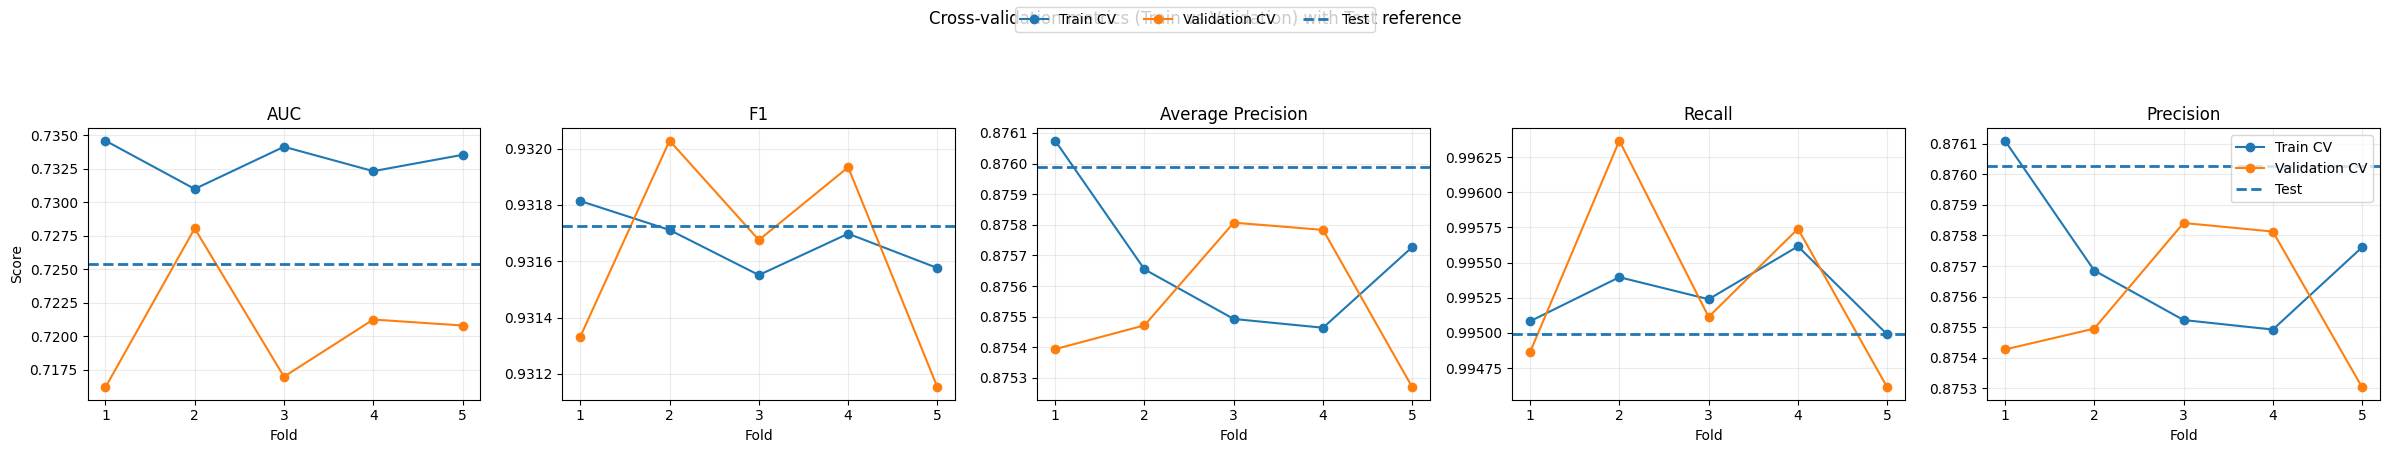

In [152]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

## Experiment 3

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french.

Vectorizer:
- Embeddings (word2vec)

Model:
- Logistic Regression